## Programming Exercise 10

### Setup
This loads the required modules. No other modules are necessary to successfully finish this exercise.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float

### 10.1 Block Matching Motion Estimation

#### 10.1.1 

Load the two video frames `frame1.png` and `frame2.png` from the `resources` folder and convert them to floating point format. Display both frames.

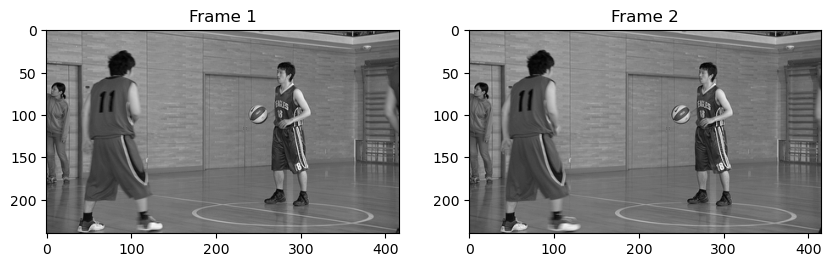

In [7]:
img1=img_as_float(io.imread('./resources/frame1.png'))
img2=img_as_float(io.imread('./resources/frame2.png'))
fig,ax=plt.subplots(1,2,figsize=(10,6))
ax[0].imshow(img1,cmap='gray')
ax[0].set_title('Frame 1')
ax[1].imshow(img2,cmap='gray')
ax[1].set_title('Frame 2')
plt.show()

#### 10.1.2

Write a function `compute_ssd(block_reference, block_moved)` that calculates the sum of squared differences between `block_reference` and `block_moved`.

In [3]:
def compute_ssd(block_reference,block_moved):
    block_reference=np.array(block_reference)
    block_moved=np.array(block_moved)
    ssd=np.sum((block_reference-block_moved)**2)
    return ssd
    

#### 10.1.3

Write a function `motion_search(block_index, image_reference, image_moved, block_size, search_range)` that performs a full search in order to search for the motion vector that describes the motion between the original block with index `block_index` in the reference image and a shifted block in the moved image.

**Caution: The given moved image `image_moved` is padded by `search_range` pixels to all sides**.

*Tip: Proceed as follows*:
1. Calculate the block position in the reference frame from the **block index** and **block size**
2. Extract the pixel values for the reference block from the reference image
3. Loop through the vertical and horizontal shifts within the search range
    1. Calculate the shifted block position in the moved frame from the **block position in the reference frame**, the **padding of the moved frame**, and the current **vertical and horizontal shift**
    2. Extract the pixel values for the moved block from the moved image
    3. Calculate the SSD (Subtask 9.1.2) between the reference block and the moved block
    4. If the SSD is the best (minimum) of all SSD values so far, remember the current vertical and horizontal shift as the best motion vector
4. Return the best motion vector

In [4]:
def motion_search(block_index,image_reference,image_moved,block_size,search_range):
    block_row,block_col=block_index
    block_pos_ref=(block_row*block_size,block_col*block_size)
    block_ref=image_reference[block_pos_ref[0]:block_pos_ref[0]+block_size,block_pos_ref[1]:block_pos_ref[1]+block_size]
    best_ssd=float('inf')
    best_mv=(0,0)
    for vertical_shift in range(-search_range, search_range + 1):
        for horizontal_shift in range(-search_range, search_range + 1):
            moved_block_row=block_pos_ref[0]+vertical_shift+search_range
            moved_block_col=block_pos_ref[1]+horizontal_shift+search_range
            block_moved=image_moved[moved_block_row:moved_block_row + block_size,moved_block_col:moved_block_col + block_size]
            ssd = compute_ssd(block_ref, block_moved)
            if ssd<best_ssd:
                best_ssd=ssd
                best_mv=(vertical_shift,horizontal_shift)
    return best_mv
    
    

#### 10.1.4

Write a function `motion_estimation(image_reference, image_moved, block_size, search_range)` that searches for the best motion vector for each block in the reference image using the function from Subtask 10.1.3. Make sure to pad the moved image by `search_range` pixels to all sides before performing the motion search.

*Hint: You can assume that the resolution of the image is divisible by the selected block size.*

In [ ]:
# import numpy as np

# def motion_estimation1(image_reference, image_moved, block_size, search_range):
#     """
#     Perform motion estimation for each block in the reference image by finding the 
#     best motion vector using the motion_search function for each block.

#     :param image_reference: The reference image.
#     :param image_moved: The moved (shifted) image.
#     :param block_size: The size of the blocks (height, width).
#     :param search_range: The range of motion search in pixels.

#     :return: A 2D array of motion vectors for each block in the reference image.
#     """
#     # Step 1: Pad the moved image by search_range pixels on all sides
#     padded_image_moved = np.pad(image_moved, ((search_range, search_range), 
#                                               (search_range, search_range)), 
#                                 mode='constant', constant_values=0)

#     # Step 2: Calculate the number of blocks in each dimension
#     height, width = image_reference.shape
#     num_blocks_vertical = height // block_size
#     num_blocks_horizontal = width // block_size

#     # Step 3: Initialize the motion vector array
#     motion_vectors = np.zeros((num_blocks_vertical, num_blocks_horizontal, 2), dtype=int)

#     # Step 4: Loop through each block in the reference image
#     for block_row in range(num_blocks_vertical):
#         for block_col in range(num_blocks_horizontal):
#             # Step 4.1: Get the block index (row, col) in the reference image
#             block_index = (block_row, block_col)
            
#             # Step 4.2: Use the motion_search function to find the motion vector for the current block
#             motion_vector = motion_search(block_index, image_reference, padded_image_moved, block_size, search_range)
            
#             # Step 4.3: Store the motion vector
#             motion_vectors[block_row, block_col] = motion_vector

#     # Step 5: Return the motion vectors
#     return motion_vectors


In [5]:
def motion_estimation(image_reference,image_moved,block_size,search_range):
    padded_img_moved=np.pad(image_moved,((search_range,search_range),(search_range,search_range)),mode='constant',constant_values=0)
    height, width = image_reference.shape
    num_blocks_vertical = height // block_size
    num_blocks_horizontal = width // block_size
    motion_vectors = np.zeros((num_blocks_vertical, num_blocks_horizontal, 2), dtype=int)
    for block_row in range(num_blocks_vertical):
        for block_col in range(num_blocks_horizontal):
            block_index = (block_row, block_col)
            motion_vector = motion_search(block_index, image_reference, padded_img_moved, block_size, search_range)
            motion_vectors[block_row, block_col] = motion_vector
    return motion_vectors

#### 10.1.5

Using the function from Subtask 10.1.4, perform a motion estimation for the two frames from Subtask 10.1.1. Display the results as an overlay on the reference image.

*Hint: The function `plt.quiver` ([docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html)) might be useful.*

In [8]:
motion_vectors=motion_estimation(img1,img2,8,4)
motion_vectors

array([[[ 0,  0],
        [ 0,  0],
        [ 0,  0],
        ...,
        [ 0,  0],
        [ 0,  0],
        [ 0,  0]],

       [[ 0,  0],
        [ 0,  0],
        [ 0,  0],
        ...,
        [ 0,  0],
        [ 0,  0],
        [ 0,  0]],

       [[ 0,  0],
        [ 0,  0],
        [ 0,  0],
        ...,
        [ 0,  0],
        [ 0,  0],
        [ 0,  0]],

       ...,

       [[ 0,  0],
        [ 0,  0],
        [ 0,  0],
        ...,
        [ 0,  0],
        [ 0,  0],
        [ 0,  0]],

       [[ 0,  0],
        [ 0,  0],
        [ 0,  0],
        ...,
        [ 0,  0],
        [ 0,  0],
        [-1,  0]],

       [[ 0,  0],
        [ 0,  0],
        [ 0,  0],
        ...,
        [ 0,  0],
        [ 0,  0],
        [ 0,  0]]])